In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv("diabetes.csv")

In [3]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


In [43]:
x= data[['BloodPressure','BMI','SkinThickness']]

In [44]:
x

,BloodPressure,BMI,SkinThickness
0,72,33.6,35
1,66,26.6,29
2,64,23.3,0
3,66,28.1,23
4,40,43.1,35
...,...,...,...
763,76,32.9,48
764,70,36.8,27
765,72,26.2,23
766,60,30.1,0


C:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


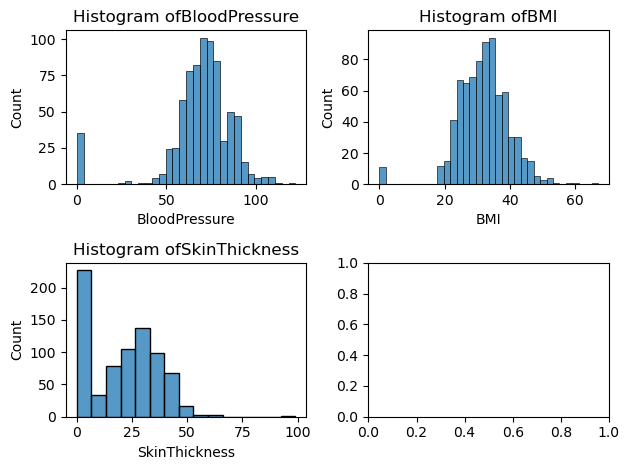

In [45]:
fig, axs = plt.subplots(2,2)

###Flatter the subpots array into a 1D array
axs = axs.ravel()

###Iterate over the columns of the X DataFrame and their corresponding subplot axes
for i, col in enumerate(x.columns):
    #plot a histogram of the current column on the corresponding subplot axis
    sns.histplot(x[col], ax = axs[i])
    
    #set the title of the subplot to indicate the column name
    axs[i].set_title('Histogram of'  + col)
    
plt.tight_layout()
plt.show()

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the envir

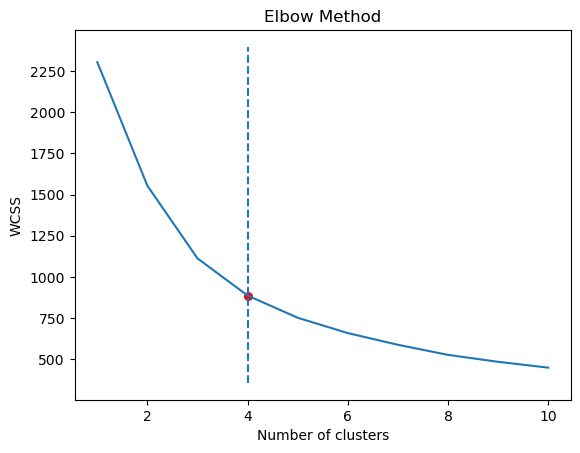

In [46]:
#create a StandardScaler object
scaler = StandardScaler()

#scale the data using the fit_transform method
X_scaled = scaler.fit_transform(x)

#compute WCSS for different values if k
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
#plot wcss vs no. of clusters
sns.lineplot(x=range(1,11), y=wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

#find the knee location
knee = KneeLocator(range(1,11),wcss, curve='convex', direction='decreasing')

#plot the knee location
plt.vlines(knee.knee, plt.ylim()[0],plt.ylim()[1], linestyles='dashed')
plt.scatter(knee.knee,knee.knee_y,color='red', s=30)

plt.show()

In [47]:
#instantiate a KMeans object with 4 clustes
kmeans = KMeans(n_clusters=4,random_state=42)

#fit the K-Means model to the scaled data and obtain the cluster labels for
y_kmeans= kmeans.fit_predict(X_scaled)

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [48]:
#add the cluster labels to the original data
data['cluster']= y_kmeans

In [49]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,cluster
0,6,148,72,35,0,33.6,0.627,50,1,2
1,1,85,66,29,0,26.6,0.351,31,0,1
2,8,183,64,0,0,23.3,0.672,32,1,0
3,1,89,66,23,94,28.1,0.167,21,0,1
4,0,137,40,35,168,43.1,2.288,33,1,2
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,2
764,2,122,70,27,0,36.8,0.340,27,0,2
765,5,121,72,23,112,26.2,0.245,30,0,1
766,1,126,60,0,0,30.1,0.349,47,1,0


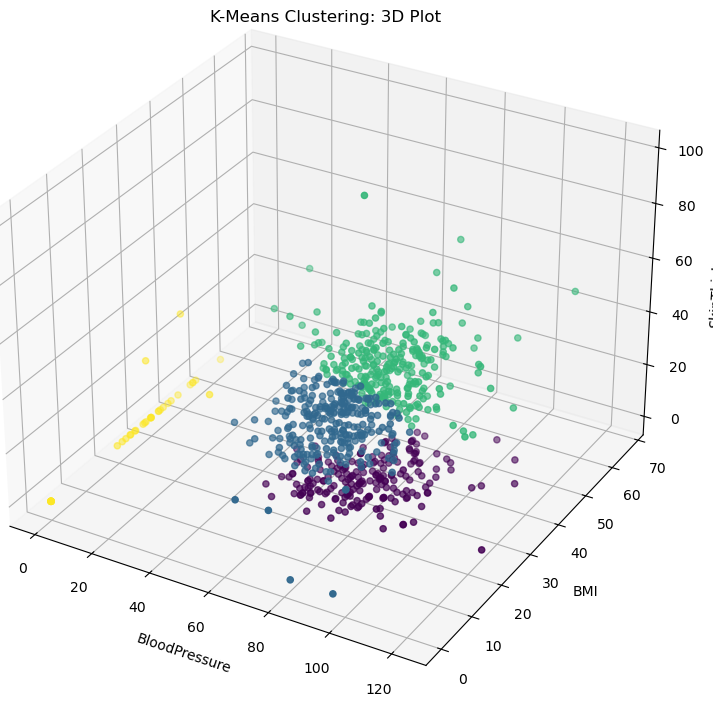

In [52]:
fig = plt.figure(figsize=(10,8))
ax=fig.add_subplot(111,projection='3d')

ax.scatter3D(data['BloodPressure'], data['BMI'], data['SkinThickness'],c=data['cluster'])

ax.set_xlabel('BloodPressure')
ax.set_ylabel('BMI')
ax.set_zlabel('SkinThickness')

plt.title('K-Means Clustering: 3D Plot')

ax.set_box_aspect(aspect=None, zoom=1.2)
plt.show()